# SINAN data engineering

This notebook cleans and prepares `sinan-db.csv` using the same feature logic described in `features.md` for the Recife dataset.


## Pipeline

- remove `DS_OBS`
- drop rows with no symptom/risk values
- drop columns with `>=28%` missingness except protected core fields
- translate Portuguese feature names/values
- convert age code to years
- create timeline, seasonality, composite scores, and interactions
- produce `sinan_single_type.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
SINAN_PATH = Path(os.getenv("SINAN_PATH", "../dataset/raw/Chikukunya/sinan-db.csv"))
if not SINAN_PATH.exists():
    SINAN_PATH = Path("dataset/raw/Chikukunya/sinan-db.csv")
OUTPUT_PATH = Path("sinan_fin.csv")

# minimum available rows in a column
MISSING_THRESHOLD = 0.28

RAW_SYMPTOM_RISK = [
    "FEBRE", "MIALGIA", "CEFALEIA", "EXANTEMA",
    "VOMITO", "NAUSEA", "DOR_COSTAS", "CONJUNTVIT",
    "ARTRITE", "ARTRALGIA", "PETEQUIA_N", "LEUCOPENIA",
    "LACO", "DOR_RETRO", "DIABETES", "HEMATOLOG",
    "HEPATOPAT", "RENAL", "HIPERTENSA", "ACIDO_PEPT",
    "AUTO_IMUNE"
]

RENAME = {
    "NU_NOTIFIC": "notification_id",
    "TP_NOT": "notification_type",
    "ID_AGRAVO": "disease_code",
    "DT_NOTIFIC": "notification_date",
    "SEM_NOT": "notification_epiweek",
    "NU_ANO": "notification_year",
    "SG_UF_NOT": "notification_state",
    "ID_MUNICIP": "notification_municipality",
    "ID_REGIONA": "notification_regional",
    "ID_UNIDADE": "notification_unit",
    "DT_SIN_PRI": "first_symptom_date",
    "SEM_PRI": "first_symptom_epiweek",
    "DT_NASC": "DoB",
    "NU_IDADE_N": "age_code",
    "CS_SEXO": "sex",
    "CS_GESTANT": "pregnancy_status",
    "CS_RACA": "race",
    "SG_UF": "residence_state",
    "ID_MN_RESI": "residence_municipality",
    "ID_RG_RESI": "residence_regional",
    "ID_BAIRRO": "residence_neighborhood_code",
    "NM_BAIRRO": "residence_neighborhood_name",
    "CS_ZONA": "residence_zone",
    "ID_PAIS": "residence_country",
    "DT_INVEST": "investigation_date",
    "FEBRE": "fever",
    "MIALGIA": "myalgia",
    "CEFALEIA": "headache",
    "EXANTEMA": "rash",
    "VOMITO": "vomiting",
    "NAUSEA": "nausea",
    "DOR_COSTAS": "back_pain",
    "CONJUNTVIT": "conjunctivitis",
    "ARTRITE": "arthritis",
    "ARTRALGIA": "arthralgia",
    "PETEQUIA_N": "petechiae",
    "LEUCOPENIA": "leukopenia",
    "LACO": "tourniquet_test",
    "DOR_RETRO": "retroorbital_pain",
    "DIABETES": "diabetes",
    "HEMATOLOG": "hematologic_disease",
    "HEPATOPAT": "liver_disease",
    "RENAL": "kidney_disease",
    "HIPERTENSA": "hypertension",
    "ACIDO_PEPT": "peptic_acid_disease",
    "AUTO_IMUNE": "autoimmune_disease",
    "CLASSI_FIN": "final_classification_code",
    "CRITERIO": "confirmation_criterion_code",
    "DT_ENCERRA": "closure_date",
}

SYMPTOM_FEATURES = [
    "fever", "myalgia", "headache", "rash", "vomiting", "nausea",
    "back_pain", "conjunctivitis", "arthritis", "arthralgia",
    "petechiae", "retroorbital_pain"
]

RISK_FEATURES = [
    "diabetes", "hematologic_disease", "liver_disease", "kidney_disease",
    "hypertension", "peptic_acid_disease", "autoimmune_disease"
]

BI_FEATURES = SYMPTOM_FEATURES + RISK_FEATURES

YES_NO_MAP = {
    "1": 1, "1.0": 1, 1: 1, 1.0: 1,
    "2": 0, "2.0": 0, 2: 0, 2.0: 0,
    "9": np.nan, "9.0": np.nan, 9: np.nan, 9.0: np.nan,
    "": np.nan,
    "Yes": 1, "No": 0,
    "YES": 1, "NO": 0,
    "Sim": 1, "N?o": 0, "Nao": 0,
    "SIM": 1, "NAO": 0,
}

NOTIFICATION_TYPE_MAP = {
    "1": "Negative", "1.0": "Negative",
    "2": "Individual", "2.0": "Individual",
    "3": "Outbreak", "3.0": "Outbreak",
    "4": "Aggregated", "4.0": "Aggregated",
}

SEX_MAP = {"M": "Male", "F": "Female", "I": "Unknown"}

PREGNANCY_MAP = {
    "1": "1st trimester", "1.0": "1st trimester",
    "2": "2nd trimester", "2.0": "2nd trimester",
    "3": "3rd trimester", "3.0": "3rd trimester",
    "4": "Gestational age unknown", "4.0": "Gestational age unknown",
    "5": "No", "5.0": "No",
    "6": "Not applicable", "6.0": "Not applicable",
    "9": "Unknown", "9.0": "Unknown",
}

RACE_MAP = {
    "1": "White", "1.0": "White",
    "2": "Black", "2.0": "Black",
    "3": "Asian", "3.0": "Asian",
    "4": "Brown", "4.0": "Brown",
    "5": "Indigenous", "5.0": "Indigenous",
    "9": "Unknown", "9.0": "Unknown",
}

ZONE_MAP = {
    "1": "Urban", "1.0": "Urban",
    "2": "Rural", "2.0": "Rural",
    "3": "Peri-urban", "3.0": "Peri-urban",
    "9": "Unknown", "9.0": "Unknown",
}


# Helper functions
## normalize func:
## boolean agreament:
Convert to 1 and 0
## Age converter
Age is decoded in hours, days, months and years in the original dataset -> transform to year.

## Clinical time-window categories
Sort them by days
- `very early`: 0-1
- `early acute`: 2-3
- `mid-acute`: 4-5
- `late acute first-week illness`: 6-7
- `subacute / persistent symptoms`: 8-14
- `prolonged illness`: 15-21
- `very prolonged illness`: 22+
#### based on dengue clinical-phase timing from WHO/CDC-style clinical guidance

## Targets with severity (for future expansion if possible)
Vision: know Dengue or not Dengue, if Dengue then goes deeper to severity

In [2]:
## Normalize val
def normalize_code_value(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

## Boolean agreement
def convert_yes_no(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    return YES_NO_MAP.get(x, YES_NO_MAP.get(s, np.nan))

## Age converter
def age_decoder(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    m = re.match(r"^(\d)(\d+)$", s)
    if not m:
        return np.nan
    unit = int(m.group(1))
    value = int(m.group(2))
    if unit == 1: # hours
        return value / (24 * 365.25)
    if unit == 2: # days
        return value / 365.25
    if unit == 3: # months
        return value / 12
    if unit == 4:
        return float(value)
    return np.nan

## clinical time-window categorization
def bin_days(series):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(pd.NA, index=s.index, dtype="object")
    out[s < 0] = "negative"
    out[(s >= 0) & (s <= 1)] = "0-1"
    out[(s >= 2) & (s <= 3)] = "2-3"
    out[(s >= 4) & (s <= 5)] = "4-5"
    out[(s >= 6) & (s <= 7)] = "6-7"
    out[(s >= 8) & (s <= 14)] = "8-14"
    out[(s >= 15) & (s <= 21)] = "15-21"
    out[s >= 22] = "22+"
    return out

## Outputs
def map_target_with_severity(x):
    x = normalize_code_value(x)
    if x == "10":
        return "Dengue_mild"
    if x == "11":
        return "Dengue_warning"
    if x == "12":
        return "Dengue_severe"
    if x == "13":
        return "Chikungunya"
    if x in {"1", "2", "5", "8"}:
        return "Other"
    return pd.NA


# Main processing pipeline
## Clean
- Any symptoms or risk NaN in any row -> removed.
- Removed columns with more than 28% missing.
* Note: for pandas, `int64` cannot handle NaN values. If a col has NaN, pd will "upcast" the col to `float64` -> ❌; `Int64` store both int and pd.NA without converting the data to floats.
## Feature Engineering
- Phase windows
- Bin age group (infant, young child, and elderly).
- Rainy season (March to August) **Based on Recife, Pernambuco, Brazil** -> later must take account into VN seasons.
## Preprocess
- Fill any Risk Features NaN with 0.

In [3]:
df = pd.read_csv(SINAN_PATH, low_memory=False)

# low_memory=False means read whole file, not in chunks. This avoids mixed dtype warnings.
df = df.replace(r"^\s*$", pd.NA, regex=True)
for c in ["Unnamed: 0", "index", "DS_OBS"]:
    if c in df.columns:
        df = df.drop(columns=[c])

existing_filter_cols = [c for c in RAW_SYMPTOM_RISK if c in df.columns]
df = df.dropna(subset=existing_filter_cols, how="all").copy()
missing_rate = df.isna().mean().sort_values(ascending=False)
protected = {
    "CLASSI_FIN", "CRITERIO", "DT_SIN_PRI", "DT_NOTIFIC", "DT_INVEST",
    "NU_IDADE_N", "CS_SEXO", "CS_GESTANT", "CS_RACA"
} | set(existing_filter_cols)
cols_del = [
    c for c in missing_rate[missing_rate >= MISSING_THRESHOLD].index.tolist()
    if c not in protected
]
df = df.drop(columns=cols_del).copy()

df = df.rename(columns={k: v for k, v in RENAME.items() if k in df.columns})

# Boolean matching
for c in BI_FEATURES:
    if c in df.columns:
        df[c] = df[c].map(convert_yes_no).astype("Float64")

# Mapping
if "notification_type" in df.columns:
    df["notification_type"] = df["notification_type"].astype("string").map(NOTIFICATION_TYPE_MAP)
df["sex"] = df["sex"].astype("string").map(SEX_MAP)
df["pregnancy_status"] = df["pregnancy_status"].astype("string").map(PREGNANCY_MAP)
df["race"] = df["race"].astype("string").map(RACE_MAP)
if "residence_zone" in df.columns:
    df["residence_zone"] = df["residence_zone"].astype("string").map(ZONE_MAP)
df["age"] = df["age_code"].apply(age_decoder)
for c in ["notification_date", "first_symptom_date", "investigation_date", "DoB", "closure_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

df["sign_to_note"] = (df["notification_date"] - df["first_symptom_date"]).dt.days
df["note_bin"] = bin_days(df["sign_to_note"])
df["early_contact"] = df["sign_to_note"].between(0, 3, inclusive="both").astype("Int64")
df["acute_window"] = df["sign_to_note"].between(0, 7, inclusive="both").astype("Int64")
df["warning_window"] = df["sign_to_note"].between(3, 7, inclusive="both").astype("Int64")
df["subacute_window"] = df["sign_to_note"].between(8, 14, inclusive="both").astype("Int64")
df["persistent_over_14d"] = (df["sign_to_note"] > 14).astype("Int64")

df["sign_to_proper_care"] = (df["investigation_date"] - df["first_symptom_date"]).dt.days
df["proper_care_bin"] = bin_days(df["sign_to_proper_care"])
df["note_to_proper_care"] = (df["investigation_date"] - df["notification_date"]).dt.days

# Mark date the first symptom happen
df["onset_month"] = df["first_symptom_date"].dt.month.astype("Int64")
df["onset_weekofyear"] = df["first_symptom_date"].dt.isocalendar().week.astype("Int64")
df["onset_dayofyear"] = df["first_symptom_date"].dt.dayofyear.astype("Int64")
df["onset_quarter"] = df["first_symptom_date"].dt.quarter.astype("Int64")
df["in_rainy_season"] = df["onset_month"].isin([3, 4, 5, 6, 7, 8]).astype("Int64")

df["onset_month_sin"] = np.sin(df["onset_month"] * np.pi / 12)
df["onset_weekofyear_sin"] = np.sin(df["onset_weekofyear"] * np.pi / 53)
df["onset_dayofyear_sin"] = np.sin(df["onset_dayofyear"] * np.pi / 347)
df["onset_quarter_sin"] = np.sin(df["onset_quarter"] * np.pi / 4)

df["flag_notif_before_onset"] = (df.get("sign_to_note", pd.Series(np.nan, index=df.index)) < 0).astype("Int64")
df["flag_invest_before_onset"] = (df.get("sign_to_proper_care", pd.Series(np.nan, index=df.index)) < 0).astype("Int64")
df["flag_invest_before_notif"] = (df.get("note_to_proper_care", pd.Series(np.nan, index=df.index)) < 0).astype("Int64")
df["flag_negative_timeline_any"] = (
    (df["flag_notif_before_onset"] == 1) |
    (df["flag_invest_before_onset"] == 1) |
    (df["flag_invest_before_notif"] == 1)
).astype("Int64")

## Age group
df["infant_flag"] = (df["age"] < 1).astype("Int64")
df["young_child_flag"] = ((df["age"] >= 1) & (df["age"] < 5)).astype("Int64")
df["old_flag"] = (df["age"] >= 60).astype("Int64")
df["high_risk_age"] = (
    (df["infant_flag"] == 1) |
    (df["young_child_flag"] == 1) |
    (df["old_flag"] == 1)
).astype("Int64")

In [4]:
# Fill
risk = [c for c in RISK_FEATURES if c in df.columns]
df["comorbidity_count"] = df[risk].fillna(0).sum(axis=1)
df["has_chronic_risk"] = (df["comorbidity_count"] > 0).astype("Int64")
df["joint_score"] = df[["myalgia", "back_pain", "arthritis", "arthralgia"]].sum(axis=1)
df["gi_score"] = (
    df["nausea"] +
    2 * df["vomiting"] +
    0.75 * df["peptic_acid_disease"] +
    0.25 * df[["kidney_disease", "liver_disease"]].sum(axis=1)
)

df["dengue_triad"] = df[["fever", "headache", "myalgia", "retroorbital_pain"]].sum(axis=1)
df["dengue_warning_triad"] = df[["warning_window", "gi_score", "petechiae", "retroorbital_pain"]].sum(axis=1)
df["chik_triad"] = df["fever"] + 2 * df[["rash", "conjunctivitis"]].max(axis=1)
df["total_symptom_burden"] = df[SYMPTOM_FEATURES + RISK_FEATURES].sum(axis=1)
df["joint_gi_ratio"] = df["joint_score"] / (df["gi_score"] + 1)
df["dengue_warning_time_x_petechiae"] = df["warning_window"] * df["petechiae"]
df["age_x_arthritis"] = df["age"] * df["arthritis"]
df["chik_discriminant_score"] = (2 * df["arthralgia"] + 2 * df["arthritis"] + df["rash"] + df["conjunctivitis"]) - (2 * df["petechiae"] + 1.5 * df["retroorbital_pain"] + df["headache"] + df["vomiting"])
df["hemorrhagic_without_joint"] = (df["petechiae"] == 1) & (df["arthralgia"] == 0) & (df["arthritis"] == 0)
df["joint_rash_coocurrence"] = (df[["arthralgia", "arthritis"]].max(axis=1) * df[["rash", "conjunctivitis"]].max(axis=1))
df["dengue_neurological_load"] = (2 * df["retroorbital_pain"] + 1.5 * df["headache"] + df["nausea"] + df["vomiting"] + 0.5 * df["back_pain"] + df["fever"]) * (1 - df["arthralgia"]) * (1 - df["arthritis"])
df["age_sex_chik_risk"] = (df["sex"] == "Female") * (df["age"] >= 40) * df[["arthralgia", "arthritis"]].max(axis=1)

score = 0
for c in ["vomiting", "petechiae", "high_risk_age", "has_chronic_risk"]:
    if c in df.columns:
        score = score + df[c].fillna(0)
df["severe_warning"] = score

df = df.dropna(subset="final_classification_code")
df["final_classification_code"] = df["final_classification_code"].map(normalize_code_value).astype("string")
df["target_with_severity"] = df["final_classification_code"].apply(map_target_with_severity).astype("string")
df["target_with_severity"] = df["target_with_severity"].replace({
    "Dengue_warning": "Dengue_severe_or_warning",
    "Dengue_severe": "Dengue_severe_or_warning",
}).astype("string")
df["target"] = df["target_with_severity"].replace({
    "Dengue_mild": "Dengue",
    "Dengue_severe_or_warning": "Dengue",
    "Chikungunya": "Chikungunya",
    "Other": "Other",
}).astype("string")

df = df.reset_index()
df.head()

,index,notification_id,notification_type,disease_code,notification_date,notification_epiweek,notification_year,notification_state,notification_municipality,notification_regional,...,dengue_warning_time_x_petechiae,age_x_arthritis,chik_discriminant_score,hemorrhagic_without_joint,joint_rash_coocurrence,dengue_neurological_load,age_sex_chik_risk,severe_warning,target_with_severity,target
0,284,648365,Individual,A90,2015-09-01,201535,2015,13,130260,5584.0,...,0.0,0.0,-1.0,False,0.0,2.5,0.0,0.0,Other,Other
1,525,444500,Individual,A90,2015-07-06,201527,2015,13,130080,5583.0,...,0.0,0.0,-1.0,False,0.0,2.5,0.0,0.0,Other,Other
2,552,605228,Individual,A90,2015-12-15,201550,2015,13,130260,5584.0,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,Dengue_mild,Dengue
3,608,444251,Individual,A90,2015-04-29,201517,2015,13,130080,5583.0,...,0.0,0.0,0.0,False,0.0,1.0,0.0,0.0,Other,Other
4,1464,444434,Individual,A90,2015-06-22,201525,2015,13,130080,5583.0,...,0.0,0.0,0.0,False,0.0,1.0,0.0,0.0,Other,Other


In [5]:
col_del = ["onset_month", "onset_dayofyear", "onset_weekofyear", "onset_quarter",
           "notification_id", "notification_type", "disease_code", "notification_date",
           "notification_epiweek", "notification_year", "notification_state", "notification_municipality",
           "notification_regional", "notification_unit", "CS_ESCOL_N", "residence_state", "residence_municipality",
           "residence_regional", "ID_DISTRIT", "residence_neighborhood_code", "residence_neighborhood_name",
           "ID_GEO1", "ID_GEO2", "residence_zone", "residence_country", "investigation_date", "leukopenia",
           "tourniquet_test", "final_classification_code", "confirmation_criterion_code", "EVOLUCAO", "age_code",
           "closure_date", "first_symptom_epiweek", "first_symptom_date", "DoB", "index"
           ]
df = df.drop(columns=[c for c in col_del if c in df.columns])

RECIFE_FIN_COLUMNS = [
    "sex", "pregnancy_status", "race", "fever", "myalgia", "headache", "rash",
    "vomiting", "nausea", "back_pain", "conjunctivitis", "arthritis", "arthralgia",
    "petechiae", "retroorbital_pain", "diabetes", "hematologic_disease", "liver_disease",
    "kidney_disease", "hypertension", "peptic_acid_disease", "autoimmune_disease", "age",
    "sign_to_note", "note_bin", "early_contact", "acute_window", "warning_window",
    "subacute_window", "persistent_over_14d", "sign_to_proper_care", "proper_care_bin",
    "note_to_proper_care", "in_rainy_season", "onset_month_sin", "onset_weekofyear_sin",
    "onset_dayofyear_sin", "onset_quarter_sin", "flag_notif_before_onset",
    "flag_invest_before_onset", "flag_invest_before_notif", "flag_negative_timeline_any",
    "infant_flag", "young_child_flag", "old_flag", "high_risk_age", "comorbidity_count",
    "has_chronic_risk", "joint_score", "gi_score", "dengue_triad", "dengue_warning_triad",
    "chik_triad", "total_symptom_burden", "joint_gi_ratio", "dengue_warning_time_x_petechiae",
    "age_x_arthritis", "severe_warning", "target_with_severity", "target"
]

df = df[RECIFE_FIN_COLUMNS].copy()
df.head()

,sex,pregnancy_status,race,fever,myalgia,headache,rash,vomiting,nausea,back_pain,...,dengue_triad,dengue_warning_triad,chik_triad,total_symptom_burden,joint_gi_ratio,dengue_warning_time_x_petechiae,age_x_arthritis,severe_warning,target_with_severity,target
0,Female,No,Brown,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,3.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,Other,Other
1,Female,No,Brown,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,Other,Other
2,Female,Gestational age unknown,White,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Dengue_mild,Dengue
3,Male,Not applicable,Indigenous,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,Other,Other
4,Female,No,Brown,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,Other,Other


In [6]:
df.columns

Index(['sex', 'pregnancy_status', 'race', 'fever', 'myalgia', 'headache',
       'rash', 'vomiting', 'nausea', 'back_pain', 'conjunctivitis',
       'arthritis', 'arthralgia', 'petechiae', 'retroorbital_pain', 'diabetes',
       'hematologic_disease', 'liver_disease', 'kidney_disease',
       'hypertension', 'peptic_acid_disease', 'autoimmune_disease', 'age',
       'sign_to_note', 'note_bin', 'early_contact', 'acute_window',
       'warning_window', 'subacute_window', 'persistent_over_14d',
       'sign_to_proper_care', 'proper_care_bin', 'note_to_proper_care',
       'in_rainy_season', 'onset_month_sin', 'onset_weekofyear_sin',
       'onset_dayofyear_sin', 'onset_quarter_sin', 'flag_notif_before_onset',
       'flag_invest_before_onset', 'flag_invest_before_notif',
       'flag_negative_timeline_any', 'infant_flag', 'young_child_flag',
       'old_flag', 'high_risk_age', 'comorbidity_count', 'has_chronic_risk',
       'joint_score', 'gi_score', 'dengue_triad', 'dengue_warning_triad'

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38327 entries, 0 to 38326
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sex                              38327 non-null  object 
 1   pregnancy_status                 38317 non-null  object 
 2   race                             38301 non-null  object 
 3   fever                            38327 non-null  Float64
 4   myalgia                          38327 non-null  Float64
 5   headache                         38327 non-null  Float64
 6   rash                             38327 non-null  Float64
 7   vomiting                         38327 non-null  Float64
 8   nausea                           38327 non-null  Float64
 9   back_pain                        38327 non-null  Float64
 10  conjunctivitis                   38327 non-null  Float64
 11  arthritis                        38327 non-null  Float64
 12  arthralgia        

In [8]:
df.to_csv(OUTPUT_PATH)

sign_to_proper_care     8030
proper_care_bin         8030
sign_to_note            7779
note_bin                7779
note_to_proper_care     6566
onset_month_sin         5817
onset_dayofyear_sin     5817
onset_weekofyear_sin    5817
onset_quarter_sin       5817
race                      26
pregnancy_status          10
dtype: int64


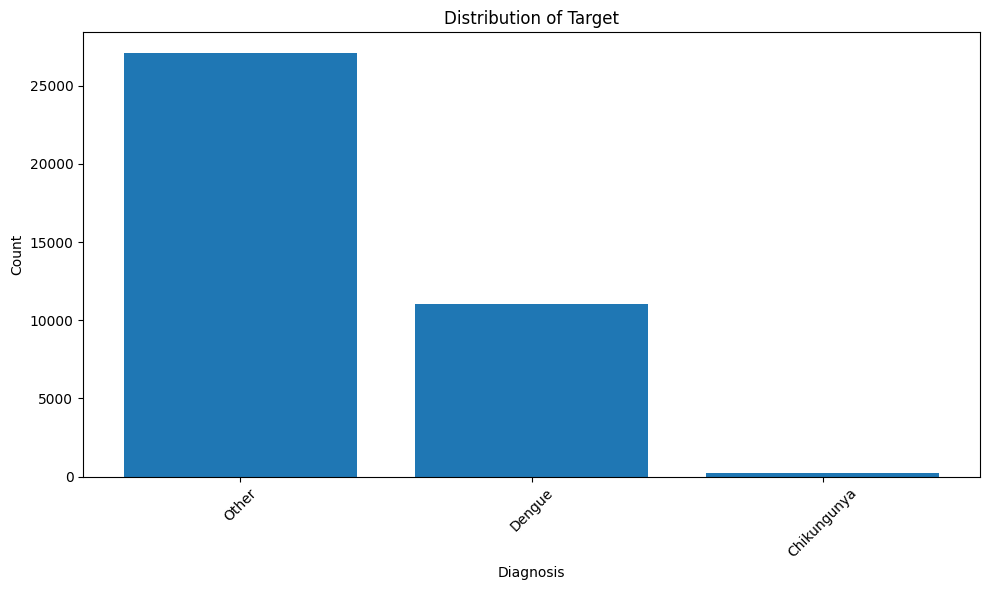

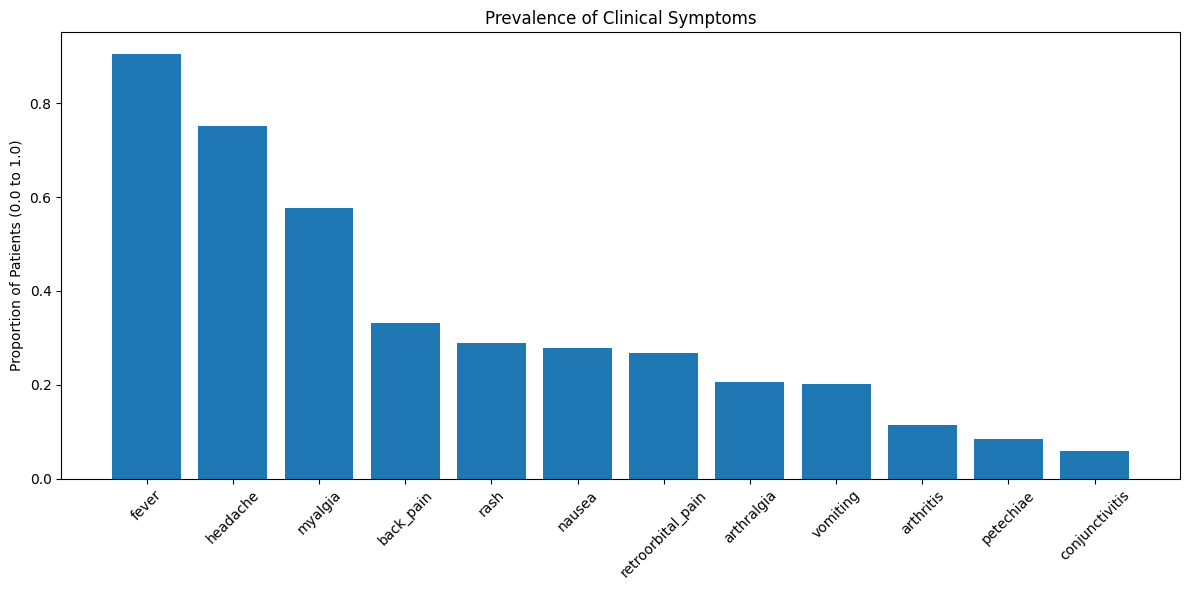

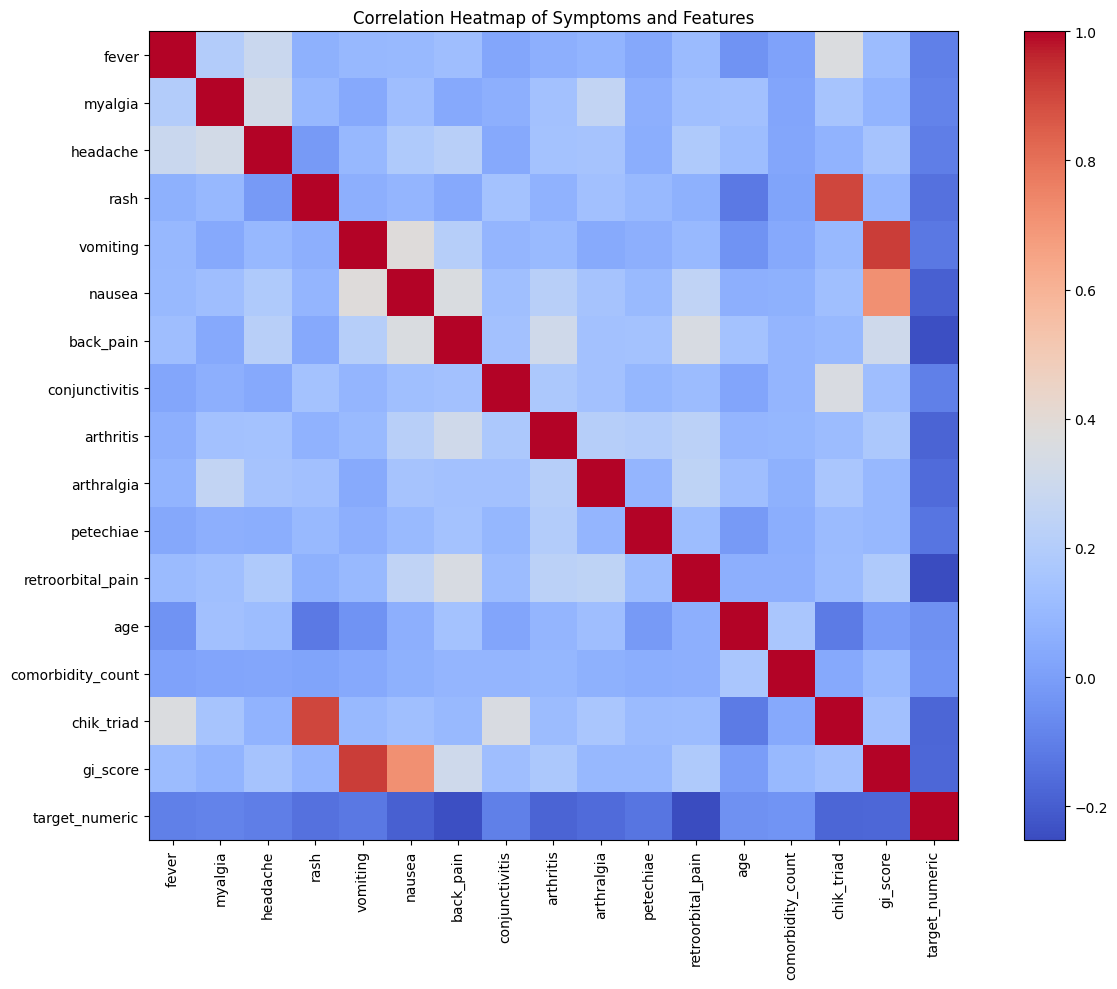

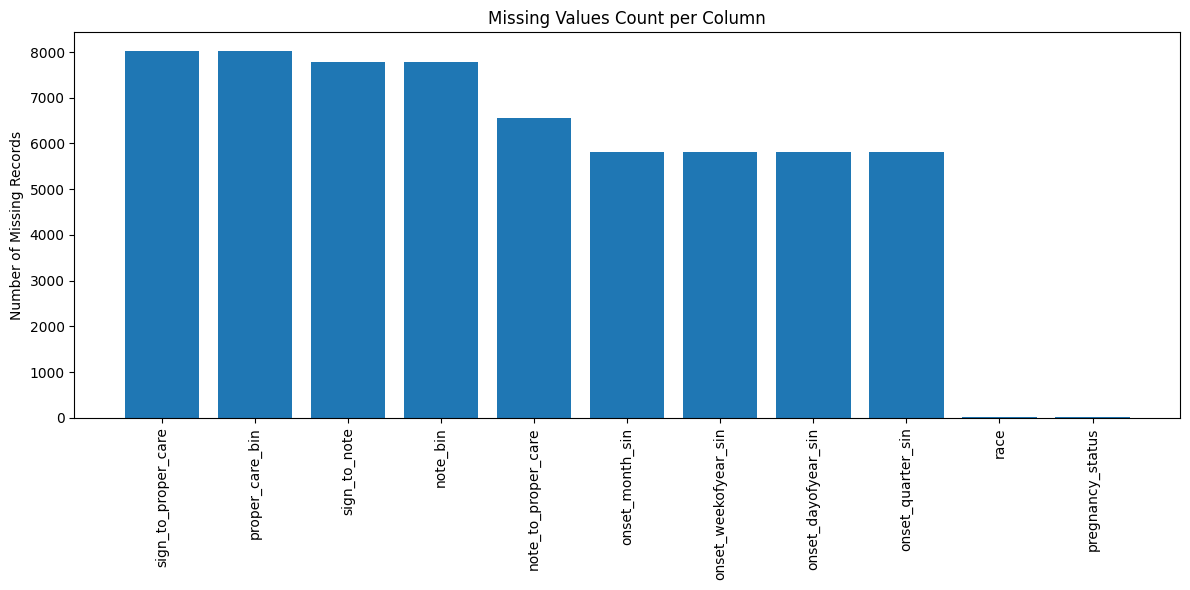

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

plt.figure(figsize=(10, 6))
df_plot = df.dropna(subset=["target"])
plt.bar(df_plot["target"].value_counts().index, df_plot["target"].value_counts().values)
plt.title("Distribution of Target")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

symptom_means = df[SYMPTOM_FEATURES].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(symptom_means.index, symptom_means.values)
plt.title("Prevalence of Clinical Symptoms")
plt.ylabel("Proportion of Patients (0.0 to 1.0)")
plt.xticks(rotation=45)
plt.tight_layout()

# Correlation Heatmap (between symptoms and target)
df["target_numeric"] = df["target"].astype("category").cat.codes

corr_features = SYMPTOM_FEATURES + ["age", "comorbidity_count", "chik_triad", "gi_score", "target_numeric"]
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap of Symptoms and Features")
plt.tight_layout()

plt.figure(figsize=(12, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    plt.bar(missing_data.index, missing_data.values)
    plt.title("Missing Values Count per Column")
    plt.xticks(rotation=90)
    plt.ylabel("Number of Missing Records")
    plt.tight_layout()
    plt.savefig("missing_values.png")

In [10]:
df["target"]


0         Other
1         Other
2        Dengue
3         Other
4         Other
          ...  
38322     Other
38323     Other
38324     Other
38325     Other
38326     Other
Name: target, Length: 38327, dtype: string